# Import Packages

In [ ]:
# import libraries
from locale import normalize
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline

import joblib
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

from keras.layers import Input, Dropout, Dense, LSTM, TimeDistributed, RepeatVector
from keras.models import Model
from keras import regularizers

# set random seed for reproduciblity
np.random.seed(10)
tf.random.set_seed(10)

# Loading Dataset

테스트용 데이터셋.

데이터셋 전처리 과정은 도메인에 맞게 준비.

In [ ]:
## Dataset loading
def data_load():
    data_dir= 'data/bearing_data'
    merged_data= pd.DataFrame()

    for filename in os.listdir(data_dir):
        dataset= pd.read_csv(os.path.join(data_dir, filename), sep='\t')
        dataset_mean_abs= np.array(dataset.abs().mean())
        dataset_mean_abs= pd.DataFrame(dataset_mean_abs.reshape(1,4))
        dataset_mean_abs.index= [filename]
        merged_data= pd.concat([merged_data, dataset_mean_abs], axis=0)

    merged_data.columns= ['Bearing_1', 'Bearing_2', 'Bearing_3', 'Bearing_4']

    ## Transform data file index to datetime and sort in chronological order
    merged_data.index= pd.to_datetime(merged_data.index, format= '%Y.%m.%d.%H.%M.%S')
    merged_data= merged_data.sort_index()
    merged_data.to_csv('Averaged_BearingTest_dataset.csv')
    print("Dataset shape:", merged_data.shape)

    ## Data split
    train= merged_data['2004-02-12 10:52:39':'2004-02-15 12:52:39']
    test= merged_data['2004-02-15 12:52:39':]
    return train, test

In [ ]:
## loading data
train, test= data_load()
print("dataset for training shape : ", train.shape)
print("datset for testing shape : ", test.shape)

Dataset shape: (982, 4)
dataset for training shape :  (445, 4)
datset for testing shape :  (538, 4)


# Visualize Data

In [ ]:
## visaulize dataset
def data_visualize(data, title):
    fig, ax= plt.subplots(figsize= (14,6), dpi=80)
    ax.plot(data['Bearing_1'], label='Bearing 1', color='blue', linewidth=1)
    ax.plot(data['Bearing_2'], label='Bearing 2', color='red', linewidth=1)
    ax.plot(data['Bearing_3'], label='Bearing 3', color='green', linewidth=1)
    ax.plot(data['Bearing_4'], label='Bearing 4', color='black', linewidth=1)
    plt.legend(loc='lower left')
    ax.set_title(title, fontsize= 16)
    plt.show()

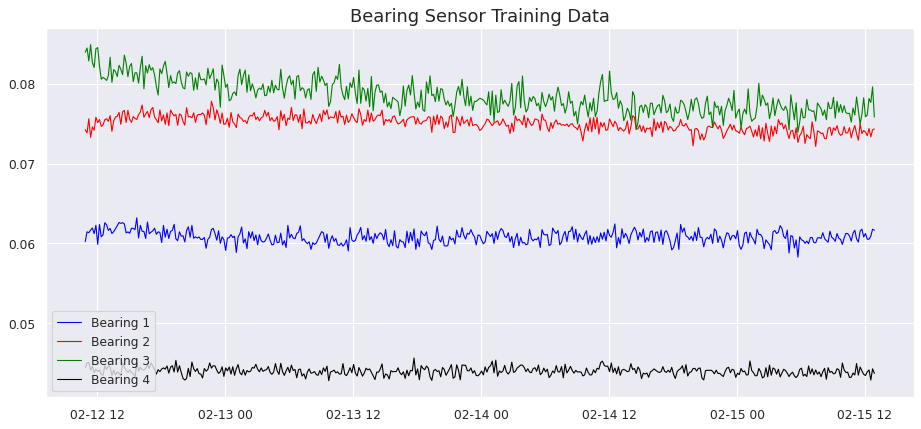

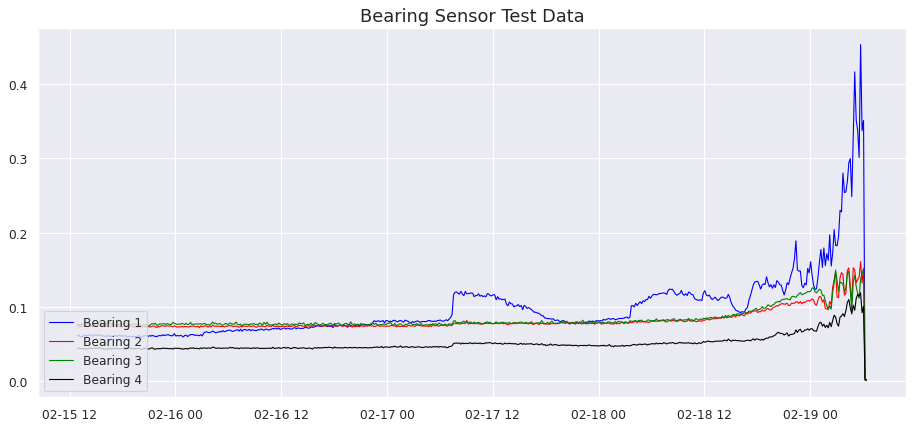

In [ ]:
data_visualize(train,'Bearing Sensor Training Data')
data_visualize(test, 'Bearing Sensor Test Data')

# Standardization

In [ ]:
## Standardizing data means that data is mapped into normal distribution.
## This helps data to be trained more effectively.

def normalize_data(train, test):
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(train)
    X_test = scaler.transform(test)
    scaler_filename = "scaler_data"
    joblib.dump(scaler, scaler_filename)
    return X_train, X_test

# Reshape

In [ ]:
## Reshaping data for training LSTM model
def reshape_data(train, test):
    ## Reshape inputs for LSTM [samples, timesteps, features]
    X_train= train.reshape(train.shape[0], 1, train.shape[1])
    X_test= test.reshape(test.shape[0], 1, test.shape[1])
    print("Training data shape : ", X_train.shape)
    print("Test data shape : ", X_test.shape)
    return X_train, X_test

In [ ]:
X_train, X_test= normalize_data(train, test)
X_train, X_test= reshape_data(X_train, X_test)

Training data shape :  (445, 1, 4)
Testing data shape :  (538, 1, 4)


# Modeling

In [ ]:
def autoencoder_model(X):
    model= tf.keras.Sequential([
        ## Encoder
        Input(shape=(X.shape[1], X.shape[2])),
        LSTM(64, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(32, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(16, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(4, activation='relu', return_sequences=False),
        ## latent vector
        RepeatVector(X.shape[1]),
        ## Decoder
        LSTM(4, activation='relu', return_sequences=True),
        LSTM(16, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(32, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(64, activation='relu', return_sequences=True),
        TimeDistributed(Dense(X.shape[2]))
    ])
    return model

In [ ]:
def modelling(X_train, epochs, batch_size):
    model= autoencoder_model(X_train)
    model.compile(optimizer='adam', loss='mae')
    model.summary()

    ## fit the model to the data
    history= model.fit(X_train, X_train, epochs=epochs, batch_size=batch_size, validation_split=0.05)
    return model, history

# Training

In [ ]:
epochs= 100
batch_size= 64

model, history= modelling(X_train, epochs, batch_size)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 1, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 1, 16)          │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 4)              │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 1, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 1, 4)           │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 1, 16)          │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ (None, 1, 32)          │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 1, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 1, 4)           │           260 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,404 (259.39 KB)

 Trainable params: 66,404 (259.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 311ms/step - loss: 0.4672 - val_loss: 0.3652
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4565 - val_loss: 0.3538
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4448 - val_loss: 0.3415
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4318 - val_loss: 0.3277
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4172 - val_loss: 0.3120
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4005 - val_loss: 0.2940
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3814 - val_loss: 0.2735
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3596 - val_loss: 0.2503
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3345 - val_loss: 0.2250
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3060 - val_loss: 0.1977
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2743 - val_loss: 0.1724
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2408 - val_

# Result

In [ ]:
def plot_fit(history):
    fig, ax= plt.subplots(figsize=(14, 6), dpi=80)
    ax.plot(history.history['loss'], 'b', label='Train', linewidth=2)
    ax.plot(history.history['val_loss'], 'r', label='Validation', linewidth=2)
    ax.set_title('Model loss', fontsize=16)
    ax.set_ylabel('Loss (mae)')
    ax.set_xlabel('Epoch')
    ax.legend(loc='upper right')
    plt.show()

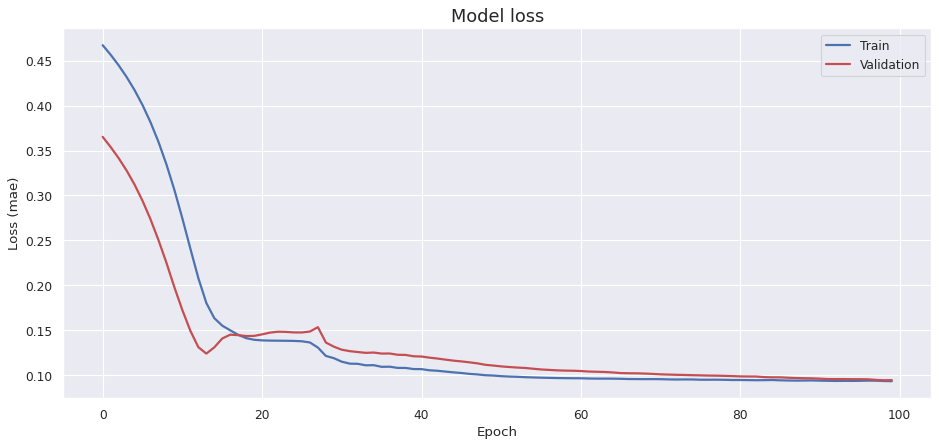

In [ ]:
plot_fit(history)

# Anomaly threshold

In [ ]:
####################################################################################################
# By plotting the distribution of the calculated loss in the training set,
# we can determine a suitable threshold value for identifying an anomaly.
## plot the loss distribution of the training set
def pred_mae_train(X_train):
    X_pred= model.predict(X_train)
    X_pred= X_pred.reshape(X_pred.shape[0], X_pred.shape[2])
    X_pred= pd.DataFrame(X_pred, columns= train.columns)
    X_pred.index= train.index

    scored= pd.DataFrame(index= train.index)
    Xtrain= X_train.reshape(X_train.shape[0], X_train.shape[2])
    scored['Loss_mae']= np.mean(np.abs(X_pred - Xtrain), axis=1)
    return scored

def pred_mae_test(X_test):
    X_pred= model.predict(X_test)
    X_pred= X_pred.reshape(X_pred.shape[0], X_pred.shape[2])
    X_pred= pd.DataFrame(X_pred, columns= test.columns)
    X_pred.index= test.index

    scored= pd.DataFrame(index= test.index)
    Xtest= X_test.reshape(X_test.shape[0], X_test.shape[2])
    scored['Loss_mae']= np.mean(np.abs(X_pred - Xtest), axis=1)
    return scored

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


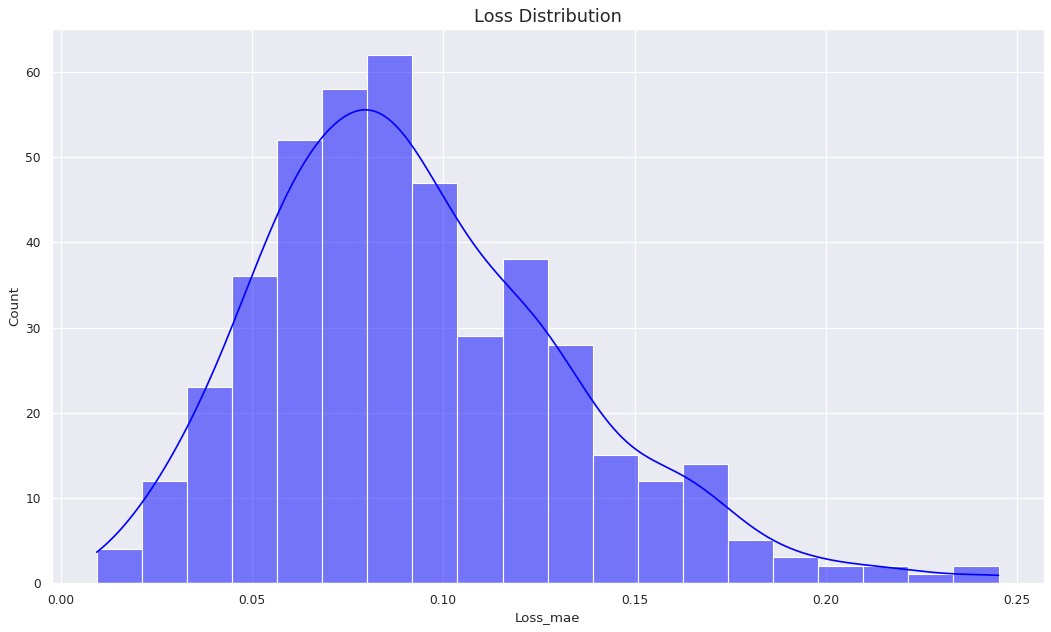

In [ ]:
scored= pred_mae_train(X_train)
plt.figure(figsize=(16,9), dpi=80)
plt.title('Loss Distribution', fontsize=16)
sns.histplot(scored['Loss_mae'], bins=20, kde=True, color='blue')
plt.show()

In [ ]:
scored['Loss_mae'].describe()

,Loss_mae
count,445.000000
mean,0.093265
std,0.040259
min,0.009457
25%,0.063472
50%,0.087501
75%,0.117878
max,0.245116


# Inference

In [ ]:
## Calculate the loss on the test set
scored_train= pred_mae_train(X_train)
scored_train['Threshold']= 0.25
scored_train['Anomaly']= scored_train['Loss_mae'] > scored_train['Threshold']

## calculate the same metrics for the training set
## & merge all data in a single dataframe
scored_test= pred_mae_test(X_test)
scored_test['Threshold']= 0.25
scored_test['Anomaly']= scored_test['Loss_mae'] > scored_test['Threshold']
scored= pd.concat([scored_train, scored_test])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


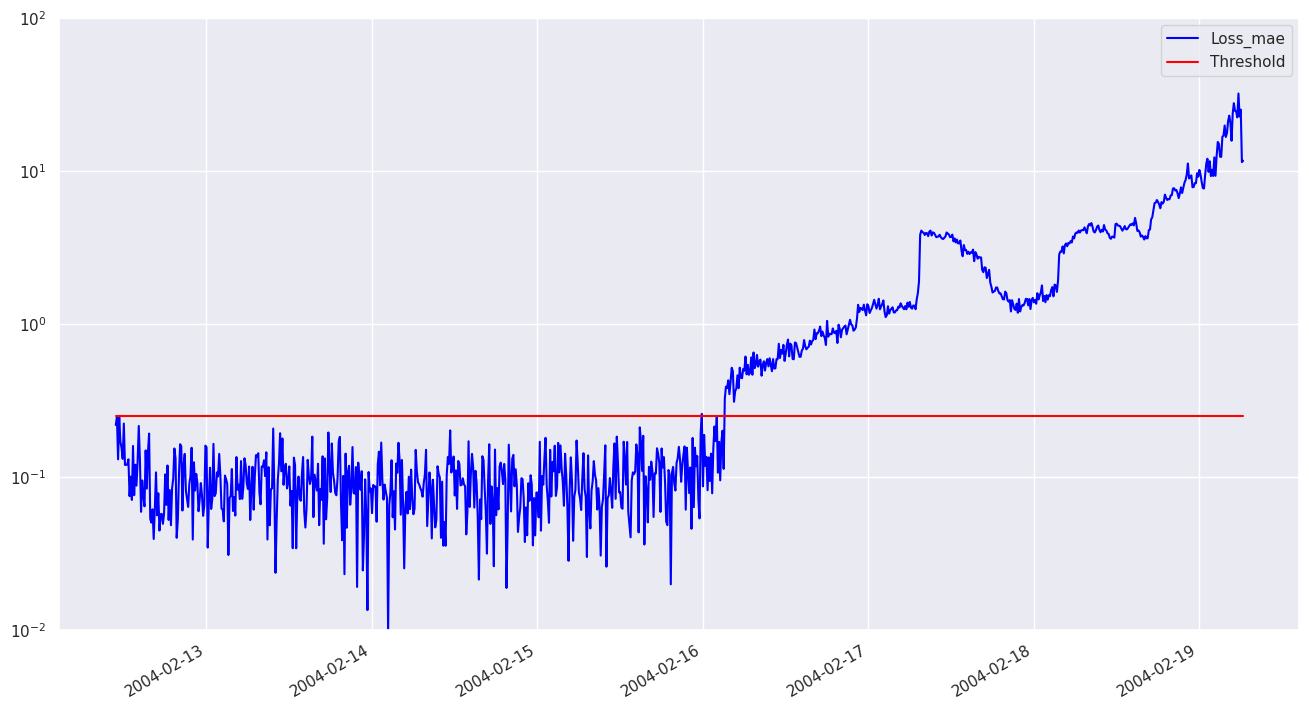

In [ ]:
## plot bearing failure timeplot
scored.plot(logy=True, figsize= (16,9), ylim= [1e-2, 1e2], color=['blue', 'red'])
plt.show()

# Anomaly Detection

In [ ]:
def vis_result(scored):
    anomaly_df= scored[scored.Anomaly == True]
    plt.plot(scored.index, scored.Loss_mae, label='loss_mae')
    plt.scatter(anomaly_df.index, anomaly_df.Loss_mae, label='anomaly_mae', color='red')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

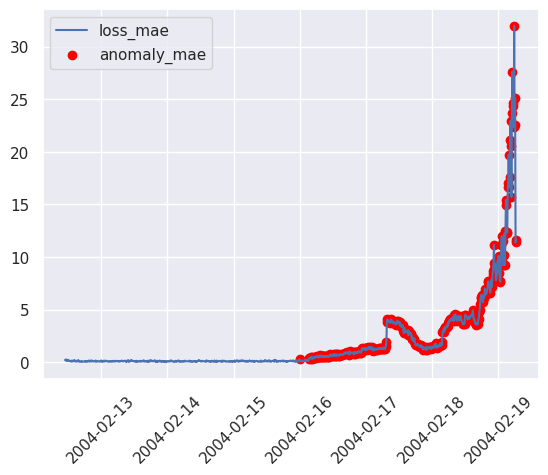

In [ ]:
vis_result(scored)